In [ ]:
print("EX5 - RNN FOR TEXT GENERATION")
print("Roll No: 24BAD116")
print("Name: SUBASRI R")


!pip -q install datasets

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print('TensorFlow Version:', tf.__version__)


EX5 - RNN FOR TEXT GENERATION
Roll No: 24BAD116
Name: SUBASRI R
TensorFlow Version: 2.20.0
Student Roll No: YOUR_ROLL_NO
Student Name: YOUR_NAME


In [ ]:
# Load Tiny Shakespeare dataset from Hugging Face
dataset = load_dataset('Trelis/tiny-shakespeare')

print(dataset)
print('\nDataset sample:\n')
print(dataset['train'][0])

README.md:   0%|          | 0.00/497 [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/119k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/472 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/49 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})

Dataset sample:

{'Text': "First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor citizens, the patricians good.\nWhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of ou

In [ ]:
# Extract and explore text
text = dataset['train'][0]['Text']

print('Total characters:', len(text))
print('\nFirst 1000 characters:\n')
print(text[:1000])

Total characters: 3131

First 1000 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this i

In [ ]:
# Convert text to lowercase
text = text.lower()
print(text[:500])

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [ ]:
# Word-level tokenization
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print('Vocabulary Size:', total_words)
print('\nFirst 20 words:')
print(list(tokenizer.word_index.items())[:20])

Vocabulary Size: 261

First 20 words:
[('<OOV>', 1), ('the', 2), ('citizen', 3), ('to', 4), ('first', 5), ('you', 6), ('we', 7), ('in', 8), ('he', 9), ('all', 10), ('is', 11), ('it', 12), ('what', 13), ('for', 14), ('not', 15), ('speak', 16), ('us', 17), ('second', 18), ('they', 19), ('i', 20)]


In [ ]:
# Convert text into integer sequence
token_list = tokenizer.texts_to_sequences([text])[0]

sequence_length = 10
input_sequences = []

for i in range(sequence_length, len(token_list)):
    sequence = token_list[i-sequence_length:i+1]
    input_sequences.append(sequence)

print('Number of sequences:', len(input_sequences))
print('First sequence:', input_sequences[0])

Number of sequences: 545
First sequence: [5, 3, 92, 7, 51, 93, 94, 95, 96, 16, 10]


In [ ]:
# Apply padding
max_sequence_length = sequence_length + 1

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_length,
        padding='pre'
    )
)

print('Shape after padding:', input_sequences.shape)
print('First padded sequence:', input_sequences[0])

Shape after padding: (545, 11)
First padded sequence: [ 5  3 92  7 51 93 94 95 96 16 10]


In [ ]:
# Separate input X and target y
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (545, 10)
y shape: (545,)


In [ ]:
# One-hot encode target labels
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

print('Final X shape:', X.shape)
print('Final y shape:', y.shape)

Final X shape: (545, 10)
Final y shape: (545, 261)


In [ ]:
# Train-validation split: 80% training, 20% validation
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]
X_val = X[split:]
y_val = y[split:]

print('Training samples:', len(X_train))
print('Validation samples:', len(X_val))

Training samples: 436
Validation samples: 109


In [ ]:
# Build Simple RNN model
model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=sequence_length
    ),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully!')

Model compiled successfully!


In [ ]:
# Train the RNN model
# Start with 10 epochs. Increase only if required and if runtime permits.
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - accuracy: 0.0069 - loss: 5.5642 - val_accuracy: 0.0092 - val_loss: 5.5553
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.0528 - loss: 5.4790 - val_accuracy: 0.0550 - val_loss: 5.5453
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0436 - loss: 5.3550 - val_accuracy: 0.0642 - val_loss: 5.5681
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.0344 - loss: 5.1941 - val_accuracy: 0.0642 - val_loss: 5.7085
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.0344 - loss: 5.0845 - val_accuracy: 0.0642 - val_loss: 5.7467
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0550 - loss: 4.9748 - val_accuracy: 0.0183 - val_loss: 5.7272
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.0757 - loss: 4.8892 - val_accuracy: 0.0183 - val_loss: 5.7786
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.0872 - loss: 4.7791 - val_accuracy: 0.0459 - val_loss: 5.8404

In [ ]:
# Evaluate training and validation performance
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)

print('Training Loss:', train_loss)
print('Training Accuracy:', train_accuracy)
print('\nValidation Loss:', val_loss)
print('Validation Accuracy:', val_accuracy)

Training Loss: 4.42728853225708
Training Accuracy: 0.18807339668273926

Validation Loss: 5.957860946655273
Validation Accuracy: 0.0458715595304966


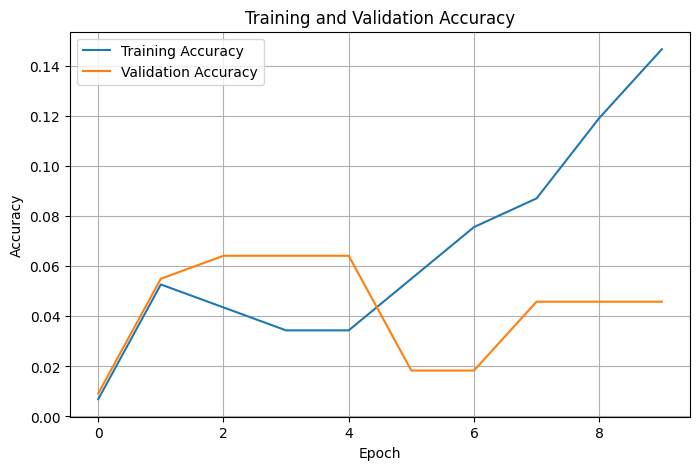

In [ ]:
# Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

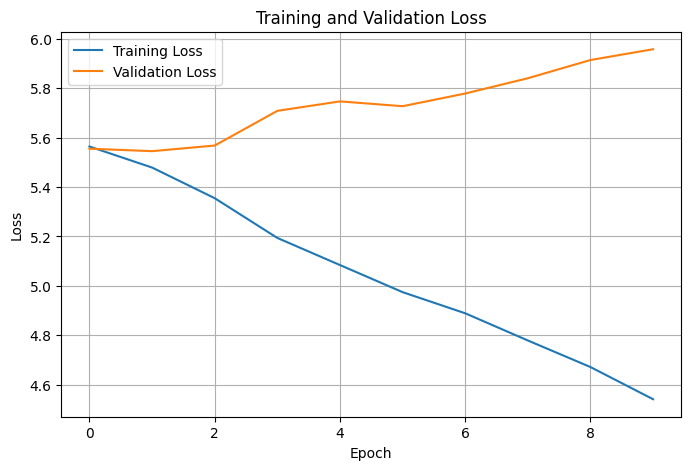

In [ ]:
# Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Text generation function
def generate_text(seed_text, next_words=20):
    generated = seed_text

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([generated])[0]
        token_list = token_list[-sequence_length:]

        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding='pre'
        )

        predicted = model.predict(token_list, verbose=0)
        predicted_word_index = np.argmax(predicted, axis=-1)[0]

        output_word = ''
        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        if not output_word:
            output_word = '<OOV>'

        generated += ' ' + output_word

    return generated

In [ ]:
# Generate multiple text samples
seeds = [
    'to be or not',
    'the king',
    'my lord',
    'what is'
]

for seed in seeds:
    print('Seed:', seed)
    print('Generated:', generate_text(seed, next_words=20))
    print('-' * 80)

Seed: to be or not
Generated: to be or not citizen he citizen citizen the the citizen the the the the citizen citizen the you citizen citizen citizen the you
--------------------------------------------------------------------------------
Seed: the king
Generated: the king all first citizen all you citizen citizen the citizen the the to the the citizen citizen the citizen citizen the
--------------------------------------------------------------------------------
Seed: my lord
Generated: my lord us he citizen all first citizen we the citizen the the citizen the the citizen the citizen citizen the the
--------------------------------------------------------------------------------
Seed: what is
Generated: what is us first citizen all first citizen we the citizen the the to the the citizen the citizen citizen citizen the
--------------------------------------------------------------------------------


In [ ]:
# Save the trained model
model.save('rnn_text_generation_model.keras')
print('Model saved as rnn_text_generation_model.keras')

Model saved as rnn_text_generation_model.keras
